# Robot Navigation Q-Learning

## 1. Imports

In [420]:
import random
import numpy as np
import matplotlib.pyplot as plt

## 2. Hyperparameters

In [421]:
# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)

# Global Parameters
SIZE = 5

actions = [
    (-1, 0),  # Up
    (1, 0),   # Down
    (0, -1),  # Left
    (0, 1)    # Right
]

# Q-learning hyperparameters
alpha = 0.1
gamma = 0.9
epsilon = 0.2
episodes = 1000 # Default episodes for single-agent training
max_steps_per_episode = SIZE * SIZE * 5 # Max steps per episode for both training and evaluation

## 3. Environment Definition

In [422]:
# Environment setup
obstacles = [
    [1, 1],
    [2, 2],
    [3, 3]
]

# Goal positions
goal = [4, 4] # For single-agent
goal1 = [4, 4] # For multi-agent Robot 1
goal2 = [4, 3] # For multi-agent Robot 2

# Start positions
robot1_start = [0, 0]
robot2_start = [0, 1]

## Part A: Single-Agent Policy

## 4. Single-Agent Training

In [423]:
Q = {}

episode_rewards = [] # Initialize episode_rewards here to ensure a fresh start

# episodes and max_steps_per_episode are now defined globally

for episode in range(episodes):
    total_reward = 0 # Initialize total_reward for each episode
    steps_taken = 0

    robot = robot1_start.copy() # Use global start position for single robot

    while robot != goal and steps_taken < max_steps_per_episode:
        steps_taken += 1

        state = tuple(robot)

        if state not in Q:
            Q[state] = [0, 0, 0, 0]

        # Exploration
        if random.random() < epsilon:
            action = random.randint(0, 3)

        # Exploitation
        else:
            action = np.argmax(Q[state]) # Changed to np.argmax for consistency

        move = actions[action]

        new_x = max(0, min(SIZE-1, robot[0] + move[0]))
        new_y = max(0, min(SIZE-1, robot[1] + move[1]))

        reward = -1

        # Integrate obstacle logic directly into the Q-learning loop
        if [new_x, new_y] in obstacles:
            reward = -20  # Penalty for hitting an obstacle
            new_x, new_y = robot # Robot stays in the current state if it hits an obstacle

        # Check if the new position is the goal
        elif [new_x, new_y] == goal:
            reward = 100

        total_reward += reward # Accumulate reward during the episode

        next_state = (new_x, new_y)

        if next_state not in Q:
            Q[next_state] = [0, 0, 0, 0]

        Q[state][action] = Q[state][action] + alpha * (
            reward +
            gamma * np.max(Q[next_state]) # Changed to np.max for consistency
            - Q[state][action]
        )

        robot = [new_x, new_y]

    episode_rewards.append(total_reward) # Append total_reward at the end of the episode

print("Training Complete")

Training Complete


## 5. Single-Agent Evaluation

In [424]:
robot = robot1_start.copy() # Use the global robot1_start

print("\nLearned Path:")

# Keep track of visited states to avoid infinite loops in case of suboptimal Q-values
visited_states = set()

max_eval_steps = SIZE * SIZE * 5 # Limit steps for evaluation, consistent with training
steps = 0
collisions_eval_single = 0 # Track collisions for single agent evaluation

while robot != goal:
    steps += 1
    if steps > max_eval_steps:
        print(f"Evaluation stopped after {max_eval_steps} steps due to max_eval_steps limit.")
        break

    current_robot_tuple = tuple(robot)
    if current_robot_tuple in visited_states:
        print("Detected loop or suboptimal policy, breaking out.")
        break
    visited_states.add(current_robot_tuple)

    print(robot)

    state = tuple(robot)

    if state not in Q:
        print(f"Warning: State {state} not found in Q-table. Robot might be stuck or policy is undefined.")
        break # Exit if state not learned

    action = np.argmax(Q[state]) # Changed to np.argmax for consistency

    move = actions[action]

    new_x = max(0, min(SIZE-1, robot[0] + move[0]))
    new_y = max(0, min(SIZE-1, robot[1] + move[1]))

    # Re-apply obstacle check to the path generation to ensure the visualization respects the learned policy
    # If the learned policy tries to move into an an obstacle, the robot should stay in its current position.
    # This matches the training logic.
    if [new_x, new_y] in obstacles:
        collisions_eval_single += 1 # Increment collision counter
        # Robot stays in current position if it tries to move into an obstacle
        pass # new_x, new_y remain the same as robot[0], robot[1] if the move was into an obstacle
    else:
        robot = [new_x, new_y]


print(goal)

success_single = (robot == goal)
print(f"Evaluation complete in {steps} steps.")
print("Success:", success_single)
print("Steps:", steps)
print("Collisions:", collisions_eval_single)


Learned Path:
[0, 0]
[1, 0]
[2, 0]
[3, 0]
[3, 1]
[3, 2]
[4, 2]
[4, 3]
[4, 4]
Evaluation complete in 8 steps.
Success: True
Steps: 8
Collisions: 0


## 6. Single-Agent Results

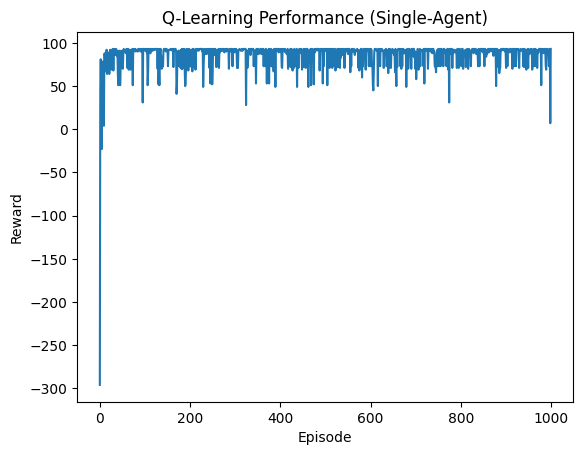

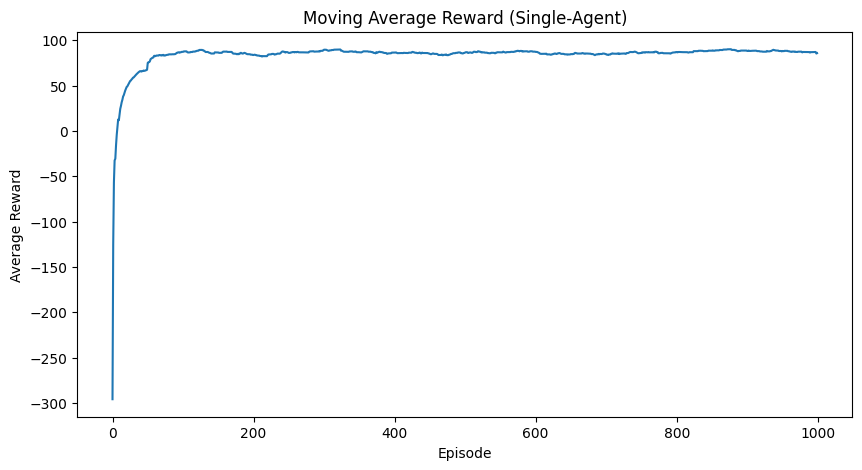

In [425]:
plt.plot(episode_rewards)
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Q-Learning Performance (Single-Agent)")
plt.show()

window = 50

moving_avg = []

for i in range(len(episode_rewards)):
    start = max(0, i - window + 1)
    moving_avg.append(
        sum(episode_rewards[start:i+1]) /
        len(episode_rewards[start:i+1])
    )

plt.figure(figsize=(10,5))
plt.plot(moving_avg)
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.title("Moving Average Reward (Single-Agent)")
plt.show()

## 7. Multi-Agent Training

In [426]:
Q1 = {}
Q2 = {}

episode_rewards_r1 = []
episode_rewards_r2 = []

# episodes and max_steps_per_episode are now defined globally

for episode in range(episodes):
    total_reward_r1 = 0
    total_reward_r2 = 0
    steps_taken = 0

    robot1 = robot1_start.copy()
    robot2 = robot2_start.copy()

    # Loop until both robots reach their goals or max steps are reached
    while (robot1 != goal1 or robot2 != goal2) and steps_taken < max_steps_per_episode:
        steps_taken += 1

        # Define current state for each robot (includes other robot's position)
        state1 = (tuple(robot1), tuple(robot2))
        state2 = (tuple(robot2), tuple(robot1))

        if state1 not in Q1:
            Q1[state1] = [0, 0, 0, 0]
        if state2 not in Q2:
            Q2[state2] = [0, 0, 0, 0]

        # Action selection for Robot 1 (epsilon-greedy)
        if random.random() < epsilon:
            action1 = random.randint(0, 3)
        else:
            action1 = np.argmax(Q1[state1])

        # Action selection for Robot 2 (epsilon-greedy)
        if random.random() < epsilon:
            action2 = random.randint(0, 3)
        else:
            action2 = np.argmax(Q2[state2])

        move1 = actions[action1]
        move2 = actions[action2]

        prospective_new_x1 = max(0, min(SIZE-1, robot1[0] + move1[0]))
        prospective_new_y1 = max(0, min(SIZE-1, robot1[1] + move1[1]))

        prospective_new_x2 = max(0, min(SIZE-1, robot2[0] + move2[0]))
        prospective_new_y2 = max(0, min(SIZE-1, robot2[1] + move2[1]))

        # Initialize rewards for the current step
        reward1 = -1
        reward2 = -1

        # Collision with obstacles for Robot 1
        if [prospective_new_x1, prospective_new_y1] in obstacles:
            reward1 -= 20
            new_x1, new_y1 = robot1 # Robot stays put if it hits an obstacle
        else:
            new_x1, new_y1 = prospective_new_x1, prospective_new_y1

        # Collision with obstacles for Robot 2
        if [prospective_new_x2, prospective_new_y2] in obstacles:
            reward2 -= 20
            new_x2, new_y2 = robot2 # Robot stays put if it hits an obstacle
        else:
            new_x2, new_y2 = prospective_new_x2, prospective_new_y2

        # Collision between robots
        if [new_x1, new_y1] == [new_x2, new_y2]:
            reward1 -= 50
            reward2 -= 50
            # Option: Robots stay in place or get pushed back
            new_x1, new_y1 = robot1
            new_x2, new_y2 = robot2

        # Goal rewards (more specific to prevent swapping)
        if [new_x1, new_y1] == goal1:
            reward1 += 100 # Reaching own goal is good
        elif [new_x1, new_y1] == goal2: # Reaching other robot's goal
            reward1 -= 75 # Penalty for reaching wrong goal

        if [new_x2, new_y2] == goal2:
            reward2 += 100 # Reaching own goal is good
        elif [new_x2, new_y2] == goal1: # Reaching other robot's goal
            reward2 -= 75 # Penalty for reaching wrong goal

        # Bonus if both robots reach their *correct* goals
        if [new_x1, new_y1] == goal1 and [new_x2, new_y2] == goal2:
            reward1 += 50
            reward2 += 50

        # Accumulate total rewards for the episode
        total_reward_r1 += reward1
        total_reward_r2 += reward2

        # Update Q-values for Robot 1
        next_state1 = (tuple([new_x1, new_y1]), tuple([new_x2, new_y2]))
        if next_state1 not in Q1:
            Q1[next_state1] = [0, 0, 0, 0]
        Q1[state1][action1] = Q1[state1][action1] + alpha * (
            reward1 + gamma * np.max(Q1[next_state1]) - Q1[state1][action1]
        )

        # Update Q-values for Robot 2
        next_state2 = (tuple([new_x2, new_y2]), tuple([new_x1, new_y1]))
        if next_state2 not in Q2:
            Q2[next_state2] = [0, 0, 0, 0]
        Q2[state2][action2] = Q2[state2][action2] + alpha * (
            reward2 + gamma * np.max(Q2[next_state2]) - Q2[state2][action2]
        )

        robot1 = [new_x1, new_y1]
        robot2 = [new_x2, new_y2]

    episode_rewards_r1.append(total_reward_r1)
    episode_rewards_r2.append(total_reward_r2)

print("Multi-robot training complete!")

Multi-robot training complete!


## 8. Multi-Agent Evaluation

Evaluating greedy policy...
Evaluation complete in 15 steps.
Success: True
Steps: 15
Collisions (Robot 1 with obstacle): 0
Collisions (Robot 2 with obstacle): 0
Collisions (Robot 1 and Robot 2): 0
Final position Robot 1: [4, 4]
Final position Robot 2: [4, 3]


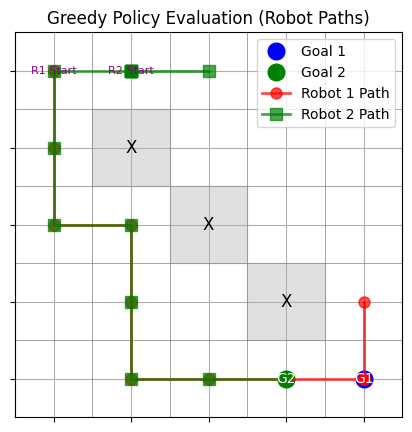

In [427]:
epsilon_original = epsilon # Store original epsilon
epsilon = 0 # Set epsilon to 0 for greedy policy

# Reset robot positions to start
robot1_eval = robot1_start.copy()
robot2_eval = robot2_start.copy()

path1 = [robot1_eval.copy()]
path2 = [robot2_eval.copy()]

max_eval_steps = SIZE * SIZE * 5 # Max steps to prevent infinite loops during evaluation
step_count = 0
collisions_robot1 = 0
collisions_robot2 = 0
robot_collisions = 0

# Initialize Q-tables if they are not already initialized. This is a failsafe for evaluation.
if 'Q1' not in globals():
    Q1 = {}
if 'Q2' not in globals():
    Q2 = {}

print("Evaluating greedy policy...")

while (robot1_eval != goal1 or robot2_eval != goal2) and step_count < max_eval_steps:
    step_count += 1

    state1 = (tuple(robot1_eval), tuple(robot2_eval))
    state2 = (tuple(robot2_eval), tuple(robot1_eval))

    # Get greedy action for Robot 1
    if state1 in Q1:
        action1 = np.argmax(Q1[state1])
    else:
        print(f"Warning: State {state1} not found in Q1 during greedy evaluation. Breaking.")
        break # Break if state not seen

    # Get greedy action for Robot 2
    if state2 in Q2:
        action2 = np.argmax(Q2[state2])
    else:
        print(f"Warning: State {state2} not found in Q2 during greedy evaluation. Breaking.")
        break # Break if state not seen

    move1 = actions[action1]
    move2 = actions[action2]

    prospective_new_x1 = max(0, min(SIZE-1, robot1_eval[0] + move1[0]))
    prospective_new_y1 = max(0, min(SIZE-1, robot1_eval[1] + move1[1]))

    prospective_new_x2 = max(0, min(SIZE-1, robot2_eval[0] + move2[0]))
    prospective_new_y2 = max(0, min(SIZE-1, robot2_eval[1] + move2[1]))

    # Check for obstacle collisions first
    current_robot1_pos_after_obs = robot1_eval.copy()
    current_robot2_pos_after_obs = robot2_eval.copy()

    if [prospective_new_x1, prospective_new_y1] in obstacles:
        collisions_robot1 += 1
    else:
        current_robot1_pos_after_obs = [prospective_new_x1, prospective_new_y1]

    if [prospective_new_x2, prospective_new_y2] in obstacles:
        collisions_robot2 += 1
    else:
        current_robot2_pos_after_obs = [prospective_new_x2, prospective_new_y2]

    # Check for robot-robot collision AFTER obstacle checks
    if current_robot1_pos_after_obs == current_robot2_pos_after_obs:
        robot_collisions += 1
        # Both robots stay in their previous position if they collide
        new_x1, new_y1 = robot1_eval[0], robot1_eval[1]
        new_x2, new_y2 = robot2_eval[0], robot2_eval[1]
    else:
        new_x1, new_y1 = current_robot1_pos_after_obs
        new_x2, new_y2 = current_robot2_pos_after_obs

    robot1_eval = [new_x1, new_y1]
    robot2_eval = [new_x2, new_y2]

    path1.append(robot1_eval.copy())
    path2.append(robot2_eval.copy())

# Restore original epsilon
epsilon = epsilon_original

success = (
    robot1_eval == goal1 and
    robot2_eval == goal2
)

print(f"Evaluation complete in {step_count} steps.")
print("Success:", success)
print("Steps:", step_count)
print(f"Collisions (Robot 1 with obstacle): {collisions_robot1}")
print(f"Collisions (Robot 2 with obstacle): {collisions_robot2}")
print(f"Collisions (Robot 1 and Robot 2): {robot_collisions}")
print(f"Final position Robot 1: {robot1_eval}")
print(f"Final position Robot 2: {robot2_eval}")

# Visualize the paths
fig, ax = plt.subplots(figsize=(SIZE, SIZE))

# Draw grid
for x in range(SIZE + 1):
    ax.axvline(x, color='gray', linestyle='-', linewidth=0.5)
    ax.axhline(x, color='gray', linestyle='-', linewidth=0.5)

# Plot obstacles
for obs in obstacles:
    ax.add_patch(plt.Rectangle((obs[1], obs[0]), 1, 1, color='lightgray', alpha=0.7))
    ax.text(obs[1] + 0.5, obs[0] + 0.5, 'X', ha='center', va='center', color='black', fontsize=12)

# Plot goal positions
ax.plot(goal1[1] + 0.5, goal1[0] + 0.5, 'o', color='blue', markersize=12, label='Goal 1')
ax.text(goal1[1] + 0.5, goal1[0] + 0.5, 'G1', ha='center', va='center', color='white', fontsize=10)
ax.plot(goal2[1] + 0.5, goal2[0] + 0.5, 'o', color='green', markersize=12, label='Goal 2')
ax.text(goal2[1] + 0.5, goal2[0] + 0.5, 'G2', ha='center', va='center', color='white', fontsize=10)

# Plot paths
path1_x = [p[1] + 0.5 for p in path1]
path1_y = [p[0] + 0.5 for p in path1]
ax.plot(path1_x, path1_y, 'ro-', linewidth=2, markersize=8, label='Robot 1 Path', alpha=0.7)
ax.text(path1_x[0], path1_y[0], 'R1 Start', ha='center', va='center', color='purple', fontsize=8)

path2_x = [p[1] + 0.5 for p in path2]
path2_y = [p[0] + 0.5 for p in path2]
ax.plot(path2_x, path2_y, 'gs-', linewidth=2, markersize=8, label='Robot 2 Path', alpha=0.7)
ax.text(path2_x[0], path2_y[0], 'R2 Start', ha='center', va='center', color='purple', fontsize=8)

ax.set_xlim(0, SIZE)
ax.set_ylim(0, SIZE)
ax.set_xticks(np.arange(0.5, SIZE, 1))
ax.set_yticks(np.arange(0.5, SIZE, 1))
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.invert_yaxis() # Invert y-axis to match common grid coordinate systems
ax.set_title('Greedy Policy Evaluation (Robot Paths)')
ax.legend()
plt.grid(True)
plt.show()

In [432]:
success = (
    robot1_eval == goal1 and
    robot2_eval == goal2
)

print("Mission Successful:", success)

Mission Successful: True


In [433]:
print("\n========== FINAL RESULTS ==========")

success = (
    robot1_eval == goal1 and
    robot2_eval == goal2
)

print("Mission Successful:", success)
print("Evaluation Steps:", step_count)
print("Robot 1 Final Position:", robot1_eval)
print("Robot 2 Final Position:", robot2_eval)

print("Robot 1 Obstacle Collisions:", collisions_robot1)
print("Robot 2 Obstacle Collisions:", collisions_robot2)
print("Robot-to-Robot Collisions:", robot_collisions)

print("\nHyperparameters")
print("Alpha:", alpha)
print("Gamma:", gamma)
print("Epsilon:", epsilon_original)
print("Episodes:", episodes)


========== FINAL RESULTS ==========
Mission Successful: True
Evaluation Steps: 15
Robot 1 Final Position: [4, 4]
Robot 2 Final Position: [4, 3]
Robot 1 Obstacle Collisions: 0
Robot 2 Obstacle Collisions: 0
Robot-to-Robot Collisions: 0

Hyperparameters
Alpha: 0.1
Gamma: 0.9
Epsilon: 0.2
Episodes: 1000


## 9. Multi-Agent Results

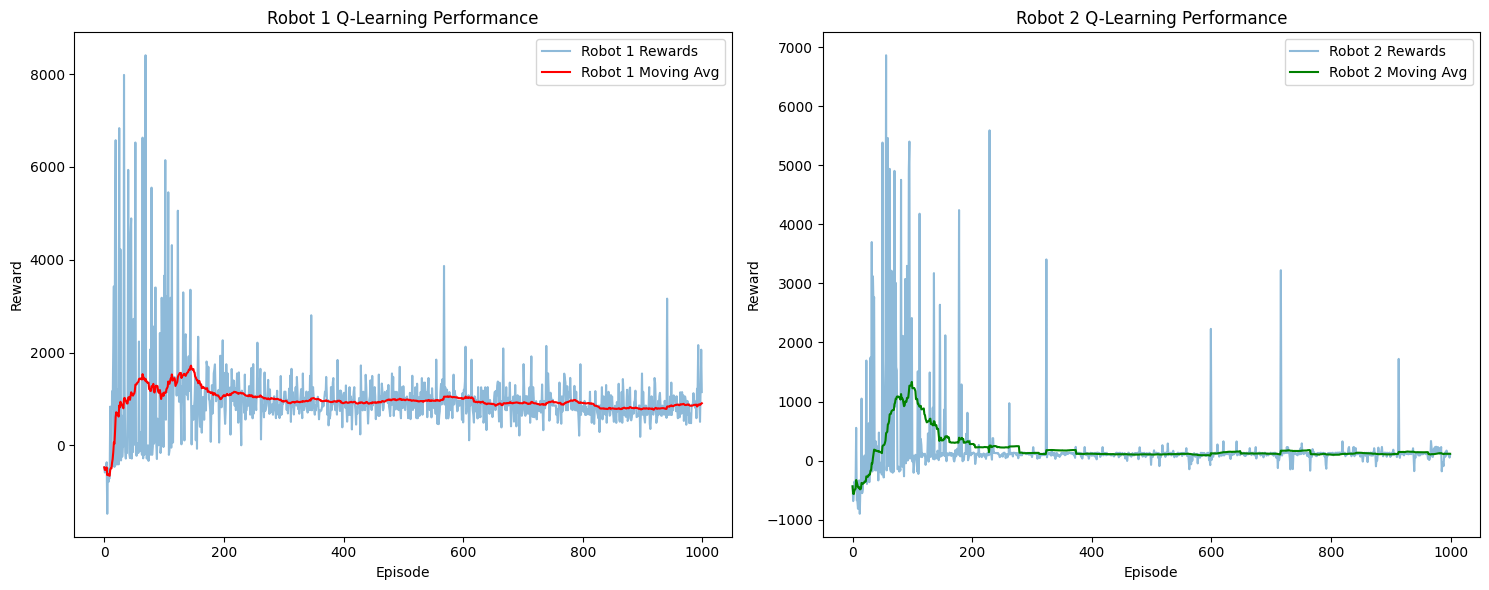

In [431]:
# Raw rewards plot

window = 50

# Calculate moving average for Robot 1
moving_avg_r1 = []
for i in range(len(episode_rewards_r1)):
    start = max(0, i - window + 1)
    moving_avg_r1.append(
        sum(episode_rewards_r1[start:i+1]) /
        len(episode_rewards_r1[start:i+1])
    )

# Calculate moving average for Robot 2
moving_avg_r2 = []
for i in range(len(episode_rewards_r2)):
    start = max(0, i - window + 1)
    moving_avg_r2.append(
        sum(episode_rewards_r2[start:i+1]) /
        len(episode_rewards_r2[start:i+1])
    )

# Plotting individual robot rewards and their moving averages
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1) # First subplot for Robot 1
plt.plot(episode_rewards_r1, label='Robot 1 Rewards', alpha=0.5)
plt.plot(moving_avg_r1, label='Robot 1 Moving Avg', color='red')
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Robot 1 Q-Learning Performance")
plt.legend()

plt.subplot(1, 2, 2) # Second subplot for Robot 2
plt.plot(episode_rewards_r2, label='Robot 2 Rewards', alpha=0.5)
plt.plot(moving_avg_r2, label='Robot 2 Moving Avg', color='green')
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Robot 2 Q-Learning Performance")
plt.legend()

plt.tight_layout()
plt.show()

## 10. Conclusion